In [3]:
%pip install msoffcrypto-tool openpyxl pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# Password-protected file access (to be used across Jupyter notebooks)

import msoffcrypto # To access password-protected files
import pandas as pd # To read and manipulate data
from io import BytesIO # Temp handling of decrypted files
from getpass import getpass # Get password input w/out encoding

password = getpass("Enter anon file password: ") # Prompt for password
decrypted_file = BytesIO() # Creates temp file in memory

with open(r"C:\Users\karin\Documents\2. Data\Anonymous_Data.xlsx", "rb") as f: # Open the password-protected file
    office_file = msoffcrypto.OfficeFile(f) # Create Officefile object
    office_file.load_key(password=password) # Load password
    office_file.decrypt(decrypted_file) # Decrypt file into memory

df = pd.read_excel(decrypted_file) # Read decrypted file into a DataFrame (DF)
df.shape # Display the shape of the DF (rows and columns)

(2839, 88)

In [16]:
df.columns.tolist() # Display column names for DF to check all columns are present and correct

['Academic Year',
 'Rand_Student_ID',
 'Year Group',
 'Department',
 'Attendance (%)',
 'Week 1 & 2 Attendance %',
 'Week 1 & 2 Attendance RAG',
 'Week 1 & 2 VLE Engagement RAG',
 'Week 1 & 2 COMBINED RAG',
 'Week 2 & 3 Attendance %',
 'Week 2 & 3 Attendance RAG',
 'Week 2 & 3 VLE Engagement RAG',
 'Week 2 & 3 COMBINED RAG',
 'Week 3 & 4 Attendance %',
 'Week 3 & 4 Attendance RAG',
 'Week 3 & 4 VLE Engagement RAG',
 'Week 3 & 4 COMBINED RAG',
 'Week 4 & 5 Attendance %',
 'Week 4 & 5 Attendance RAG',
 'Week 4 & 5 VLE Engagement RAG',
 'Week 4 & 5 COMBINED RAG',
 'Week 5 & 6 Attendance %',
 'Week 5 & 6 Attendance RAG',
 'Week 5 & 6 VLE Engagement RAG',
 'Week 5 & 6 COMBINED RAG',
 'Week 6 & 7 Attendance %',
 'Week 6 & 7 Attendance RAG',
 'Week 6 & 7 VLE Engagement RAG',
 'Week 6 & 7 COMBINED RAG',
 'Week 7 & 8 Attendance %',
 'Week 7 & 8 Attendance RAG',
 'Week 7 & 8 VLE Engagement RAG',
 'Week 7 & 8 COMBINED RAG',
 'Week 8 & 9 Attendance %',
 'Week 8 & 9 Attendance RAG',
 'Week 8 & 9 VL

In [17]:
print(df.dtypes.to_string()) # Data type for each column in DF

Academic Year                       object
Rand_Student_ID                      int64
Year Group                          object
Department                          object
Attendance (%)                     float64
Week 1 & 2 Attendance %            float64
Week 1 & 2 Attendance RAG           object
Week 1 & 2 VLE Engagement RAG       object
Week 1 & 2 COMBINED RAG             object
Week 2 & 3 Attendance %            float64
Week 2 & 3 Attendance RAG           object
Week 2 & 3 VLE Engagement RAG       object
Week 2 & 3 COMBINED RAG             object
Week 3 & 4 Attendance %            float64
Week 3 & 4 Attendance RAG           object
Week 3 & 4 VLE Engagement RAG       object
Week 3 & 4 COMBINED RAG             object
Week 4 & 5 Attendance %            float64
Week 4 & 5 Attendance RAG           object
Week 4 & 5 VLE Engagement RAG       object
Week 4 & 5 COMBINED RAG             object
Week 5 & 6 Attendance %            float64
Week 5 & 6 Attendance RAG           object
Week 5 & 6 

In [20]:
# Overall missingness check per column of DF

print(df.isnull().sum().sort_values(ascending=False).to_string()) # Shows null values per column (descending order)

check                              2566
Notes                              2538
Progression Decision (Resit)       1852
Week 1 & 2 Attendance %             129
Week 19 & 20 Attendance %           110
Week 12 & 13 Attendance %           110
Week 14 & 15 Attendance %           110
Week 11 & 12 Attendance %           110
Week 15 & 16 Attendance %           110
Week 16 & 17 Attendance %           110
Week 17 & 18 Attendance %           110
Week 18 & 19 Attendance %           110
Week 13 & 14 Attendance %           110
Week 20 & 21 Attendance %           110
Week 2 & 3 Attendance %             106
Week 3 & 4 Attendance %              90
Week 5 & 6 Attendance %              86
Week 4 & 5 Attendance %              86
Week 6 & 7 Attendance %              84
Week 7 & 8 Attendance %              82
Week 9 & 10 Attendance %             81
Week 8 & 9 Attendance %              81
Attendance (%)                       52
Week 20 & 21 VLE Engagement RAG      21
Week 15 & 16 VLE Engagement RAG      21


In [ ]:
df['Notes'].value_counts() # Check values in Notes column to ensure none are missing & cross-ref methodology write up

Notes
Unknown      167
PR/Repeat     92
O/S           42
Name: count, dtype: int64

In [ ]:
df[df['check'] == 'Yes']['Notes'].value_counts() # Check values in Notes column for rows where check column = Yes to ensure none are missing - some missing due to pre checked through student status

Notes
Unknown      167
PR/Repeat     66
O/S           40
Name: count, dtype: int64

In [29]:
%pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------------- -------------------------- 3.1/9.3 MB 15.3 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.3 MB 16.8 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 15.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 16.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


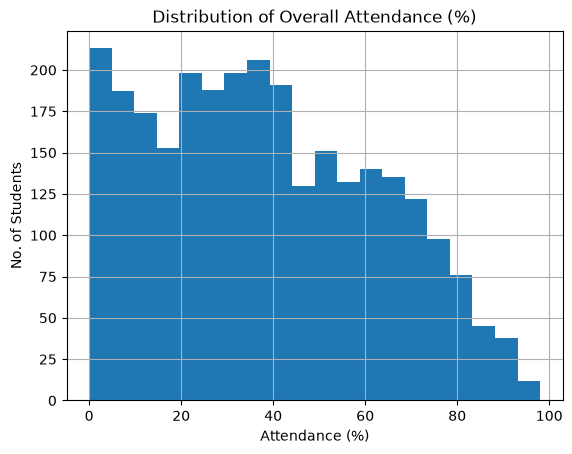

In [ ]:
# Attendance percentage distribution histogram
import matplotlib.pyplot as plt # For plotting

df['Attendance (%)'].hist(bins=20) # Histogram of overall attendance percentage
plt.title('Distribution of Overall Attendance (%)') # Title for histogram
plt.xlabel('Attendance (%)') # X-axis label
plt.ylabel('No. of Students') # Y-axis label
plt.show() # Show histogram

The Attendance % shows a left-skewed distribution, with the majority of students in the 0 - 40% region for in-person attendance as opposed to being concentrated at the higher end. This directly supports the project's argument that in-person attendance alone may not be a reliable lone predictor in the current climate. This drives for the inclusion of VLE interaction and online engagement as a contributing signal.

In [32]:
# VLE Engagement distribution

vle_columns = [col for col in df.columns if 'VLE' in col] # List VLE columns
print(vle_columns) # Display VLE columns

['Week 1 & 2 VLE Engagement RAG', 'Week 2 & 3 VLE Engagement RAG', 'Week 3 & 4 VLE Engagement RAG', 'Week 4 & 5 VLE Engagement RAG', 'Week 5 & 6 VLE Engagement RAG', 'Week 6 & 7 VLE Engagement RAG', 'Week 7 & 8 VLE Engagement RAG', 'Week 8 & 9 VLE Engagement RAG', 'Week 9 & 10 VLE Engagement RAG', 'Week 11 & 12 VLE Engagement RAG', 'Week 12 & 13 VLE Engagement RAG', 'Week 13 & 14 VLE Engagement RAG', 'Week 14 & 15 VLE Engagement RAG', 'Week 15 & 16 VLE Engagement RAG', 'Week 16 & 17 VLE Engagement RAG', 'Week 17 & 18 VLE Engagement RAG', 'Week 18 & 19 VLE Engagement RAG', 'Week 19 & 20 VLE Engagement RAG', 'Week 20 & 21 VLE Engagement RAG']


GREEN    25282
AMBER    15235
RED       9506
GREY      3708
dtype: int64


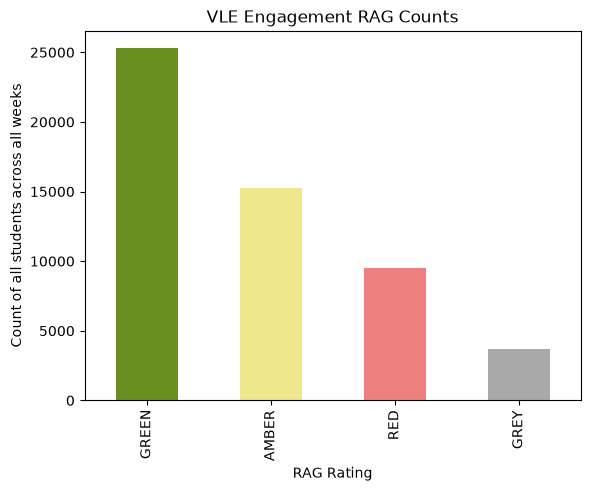

In [43]:
# VLE RAG calculations - Count occurances of each colour (Red, Amber, Green)

vle_counts = df[vle_columns].apply(pd.Series.value_counts).sum(axis=1) # Count occurrences of each value colour across VLE columns
vle_counts_sorted = vle_counts.sort_values(ascending=False) # Sort counts in descending order
print(vle_counts_sorted) # Display counts of each colour across VLE columns

vle_counts_sorted.plot(kind='bar', color=['olivedrab', 'khaki', 'lightcoral', 'darkgrey']) # Bar chart of VLE RAG counts
plt.title('VLE Engagement RAG Counts') # Title for bar chart
plt.xlabel('RAG Rating') # X-axis label
plt.ylabel('Count of all students across all weeks') # Y-axis label
plt.show() # Show bar chart

RAG Counts are as follows, from largest to smallest - Green: 25,282 | Amber: 